# IntelliPulse V3.1 — Random Forest Hyperparameter Optimization

---

## 1 · Objective

V3 established an untuned Random Forest baseline. The results at the default 0.50 threshold were:

| Metric | V3 (Random Forest) | V1 (Logistic Regression) |
|--------|--------------------|---------------------------|
| **Accuracy** | 77.71% | 80.55% |
| **Precision** | 60.07% | 65.72% |
| **Recall** | 47.86% | 55.88% |
| **F1** | 53.27% | 60.40% |
| **ROC-AUC** | 82.06% | 84.21% |

**V1 Logistic Regression remains stronger.** 

Before we conclude that Random Forest is unsuitable for this dataset, we must determine if the baseline configuration was simply sub-optimal. The default Random Forest allows trees to grow infinitely deep (`max_depth=None`), which often leads to severe overfitting on tabular data.

**The experimental question:**
*"Was V3 weak because Random Forest is fundamentally unsuited for this dataset, or because the baseline configuration was not optimal?"*

### Experimental Rules
- We **do not** modify V1, V2.1, V2.2, or V3.
- We **do not** change the train/test split.
- The **test set** remains completely untouched during hyperparameter tuning to prevent data leakage.
- We use only the training data for cross-validation.
- We **do not** optimize the decision threshold in this notebook (it remains at 0.50).

---

## 2 · Imports and Configuration

In [1]:
import os
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)

# ── Configuration ────────────────────────────────────────────────────
RANDOM_STATE = 42

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
MODEL_DIR = PROJECT_ROOT / "artifacts" / "models"
METRICS_DIR = PROJECT_ROOT / "artifacts" / "metrics"

print(f"Project root : {PROJECT_ROOT}")
print(f"Random state : {RANDOM_STATE}")

Project root : /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse
Random state : 42


---

## 3 · Load and Prepare Data

We reuse the exact same train/test split, random state, target, features, and preprocessing from previous experiments.

In [2]:
# ── Load raw data ─────────────────────────────────────────────────────
assert RAW_DATA_PATH.exists(), f"Dataset not found at {RAW_DATA_PATH}"
df_raw = pd.read_csv(RAW_DATA_PATH)
df = df_raw.copy()

# ── Fix TotalCharges ──────────────────────────────────────────────────
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)

# ── Column definitions ───────────────────────────────────────────────
ID_COL = "customerID"
TARGET_COL = "Churn"

NUMERICAL_FEATURES = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
CATEGORICAL_FEATURES = [
    "gender", "Partner", "Dependents",
    "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]

# ── Separate X and y ─────────────────────────────────────────────────
X = df.drop(columns=[ID_COL, TARGET_COL])
y = df[TARGET_COL].map({"No": 0, "Yes": 1}).astype(int)

# ── Train/Test Split (Identical to V1-V3) ────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")

Training set : 5,634 rows
Test set     : 1,409 rows


In [3]:
# ── Load prior metrics for later comparison ───────────────────────────
with open(METRICS_DIR / "baseline_v1.json") as f:
    v1_metrics = json.load(f)

with open(METRICS_DIR / "random_forest_v3.json") as f:
    v3_metrics = json.load(f)["metrics_at_050"]

print("Prior metrics loaded for V1 and V3.")

Prior metrics loaded for V1 and V3.


---

## 4 · Why Cross-Validation?

We cannot choose hyperparameters based on the test set. Doing so would turn the test set into a validation set, "leaking" its information into the model training process, and rendering the final evaluation overly optimistic.

Instead, we use **$k$-fold cross-validation** exclusively on the training data:

1. The training data is split into $k=5$ folds.
2. For each hyperparameter combination, the model is trained on 4 folds and evaluated on the 1 remaining fold. This is repeated 5 times.
3. The average score across the 5 folds determines the best configuration.
4. Only the winning configuration is finally evaluated ONCE on the untouched test set.

We use `StratifiedKFold` to ensure the 73%/27% class distribution is preserved across all folds.

---

## 5 · Preprocessing and Optimization Metric

### Preventing Data Leakage
The preprocessing (imputation, scaling, one-hot encoding) must occur *inside* the cross-validation loop. If we fit the `ColumnTransformer` on the entire training set *before* cross-validation, the imputation statistics and scaling parameters would leak information from the CV validation folds into the CV training folds. 

By wrapping the `ColumnTransformer` and `RandomForestClassifier` in a single `Pipeline`, scikit-learn ensures that preprocessing is re-fitted independently on each fold.

### Primary Optimization Metric
We optimize for **F1-score** (`scoring="f1"`). Because this is a churn prediction problem with moderate class imbalance, Accuracy can be misleading. A model that always predicts "No Churn" would be ~73% accurate but completely useless for the business. F1 balances Precision and Recall, making it a robust metric for hyperparameter selection.

In [4]:
# ── Build preprocessing pipeline ───────────────────────────────────────
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, NUMERICAL_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)

# ── Complete Pipeline ────────────────────────────────────────────────
# Note: we don't set hyperparams here; RandomizedSearchCV will inject them.
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE))
])

---

## 6 · Hyperparameter Search

We use `RandomizedSearchCV` instead of an exhaustive `GridSearchCV`. Randomized search explores a sensible parameter space much more efficiently by sampling a fixed number of combinations (`n_iter=20`).

**Parameter Space:**
- `n_estimators`: Number of trees.
- `max_depth`: Limits how deep trees can grow (crucial for preventing overfitting).
- `min_samples_split`: Minimum samples required to split an internal node.
- `min_samples_leaf`: Minimum samples required to be at a leaf node.
- `max_features`: Number of features to consider when looking for the best split.

Because our parameters apply to the `classifier` step inside the `Pipeline`, we prefix them with `classifier__`.

In [5]:
# Define the parameter grid
param_distributions = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [None, 5, 10, 15, 20, 30],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 4, 8],
    "classifier__max_features": ["sqrt", "log2", None],
}

# Define the cross-validation strategy
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Set up the randomized search
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

print("Starting RandomizedSearchCV on training data...")
random_search.fit(X_train, y_train)
print("✓ Search complete.")

Starting RandomizedSearchCV on training data...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


✓ Search complete.


---

## 7 · Search Results

Let's examine the top configurations found during cross-validation. 

> Note: `mean_test_score` in the CV results refers to the average F1 score on the **CV validation folds**. It is **not** the final test-set score.

In [6]:
print(f"Best hyperparameters found:")
for param, value in random_search.best_params_.items():
    clean_param = param.replace("classifier__", "")
    print(f"  {clean_param:20s}: {value}")

best_cv_f1 = random_search.best_score_
print(f"\nBest cross-validated F1 score: {best_cv_f1:.4f}")

Best hyperparameters found:
  n_estimators        : 300
  min_samples_split   : 10
  min_samples_leaf    : 4
  max_features        : None
  max_depth           : 10

Best cross-validated F1 score: 0.5816


In [7]:
# Convert CV results to DataFrame and display top 10
cv_results = pd.DataFrame(random_search.cv_results_)

# Clean up column names for display
display_cols = ["rank_test_score", "mean_test_score", "std_test_score"]
param_cols = [c for c in cv_results.columns if c.startswith("param_classifier__")]
display_cols.extend(param_cols)

top_configs = cv_results.sort_values("rank_test_score").head(10)[display_cols].copy()

# Rename columns to be readable
rename_dict = {c: c.replace("param_classifier__", "") for c in param_cols}
rename_dict.update({
    "rank_test_score": "Rank",
    "mean_test_score": "Mean CV F1",
    "std_test_score": "Std CV F1"
})
top_configs = top_configs.rename(columns=rename_dict)

print("Top 10 Configurations (Sorted by Mean CV F1)")
print("=" * 110)
print(top_configs.to_string(index=False))

Top 10 Configurations (Sorted by Mean CV F1)
 Rank  Mean CV F1  Std CV F1  n_estimators  min_samples_split  min_samples_leaf max_features max_depth
    1    0.581591   0.026159           300                 10                 4          NaN        10
    2    0.580426   0.017006           100                  2                 8         sqrt        10
    3    0.578767   0.033619           300                  2                 8          NaN        15
    4    0.577600   0.033508           300                 20                 4          NaN      None
    5    0.577088   0.027818           500                 10                 1          NaN        15
    6    0.576274   0.019690           500                 20                 8         sqrt        10
    7    0.574234   0.019011           200                  5                 8         sqrt        15
    8    0.573728   0.017359           300                  5                 8         log2        15
    9    0.572742   0.017922

---

## 8 · Train Final V3.1 Model

The `RandomizedSearchCV` object automatically refits the best estimator on the *entire* training set once the search is complete. We extract this optimal pipeline to serve as our final V3.1 model.

In [8]:
# The best estimator is already refitted on the full X_train, y_train
model_v3_1 = random_search.best_estimator_

# Save to disk
MODEL_DIR.mkdir(parents=True, exist_ok=True)
v3_1_model_path = MODEL_DIR / "churn_random_forest_v3_1_tuned.joblib"
joblib.dump(model_v3_1, v3_1_model_path)

print(f"✓ Tuned V3.1 Random Forest saved to: {v3_1_model_path}")
print(f"  File size: {v3_1_model_path.stat().st_size / 1024:.1f} KB")

# Verify V3 is not overwritten
assert (MODEL_DIR / "churn_random_forest_v3.joblib").exists(), "V3 model was overwritten!"
print("✓ V3 untuned model is safely preserved.")

✓ Tuned V3.1 Random Forest saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/models/churn_random_forest_v3_1_tuned.joblib
  File size: 11618.9 KB
✓ V3 untuned model is safely preserved.


---

## 9 · Final Test Evaluation (Threshold 0.50)

Now that hyperparameters are locked in, we evaluate the tuned model on the untouched test set. We strictly maintain the 0.50 threshold to isolate the effect of hyperparameter tuning from threshold optimization.

In [9]:
# ── Predictions at threshold 0.50 ────────────────────────────────────
y_pred_v3_1 = model_v3_1.predict(X_test)
y_prob_v3_1 = model_v3_1.predict_proba(X_test)[:, 1]

# ── Metrics ──────────────────────────────────────────────────────────
acc_v3_1  = accuracy_score(y_test, y_pred_v3_1)
prec_v3_1 = precision_score(y_test, y_pred_v3_1)
rec_v3_1  = recall_score(y_test, y_pred_v3_1)
f1_v3_1   = f1_score(y_test, y_pred_v3_1)
auc_v3_1  = roc_auc_score(y_test, y_prob_v3_1)

cm_v3_1 = confusion_matrix(y_test, y_pred_v3_1)
tn_v3_1, fp_v3_1, fn_v3_1, tp_v3_1 = cm_v3_1.ravel()

v3_1_metrics_050 = {
    "model": "RandomForest_Tuned_V3.1",
    "threshold": 0.50,
    "accuracy": round(acc_v3_1, 4),
    "precision": round(prec_v3_1, 4),
    "recall": round(rec_v3_1, 4),
    "f1_score": round(f1_v3_1, 4),
    "roc_auc": round(auc_v3_1, 4),
    "tp": int(tp_v3_1), "fp": int(fp_v3_1),
    "fn": int(fn_v3_1), "tn": int(tn_v3_1),
}

print("=" * 50)
print("  V3.1 (Tuned RF) — Test Set Evaluation @ 0.50")
print("=" * 50)
print(f"  Accuracy  : {acc_v3_1:.4f}")
print(f"  Precision : {prec_v3_1:.4f}")
print(f"  Recall    : {rec_v3_1:.4f}")
print(f"  F1-score  : {f1_v3_1:.4f}")
print(f"  ROC-AUC   : {auc_v3_1:.4f}")
print("=" * 50)

  V3.1 (Tuned RF) — Test Set Evaluation @ 0.50
  Accuracy  : 0.7963
  Precision : 0.6399
  Recall    : 0.5321
  F1-score  : 0.5810
  ROC-AUC   : 0.8373


### Confusion Matrix

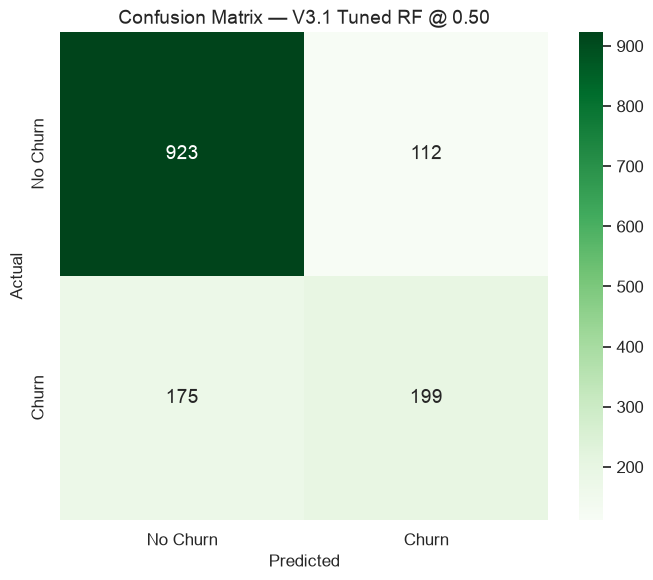

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_v3_1, annot=True, fmt="d", cmap="Greens", ax=ax,
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"],
            annot_kws={"size": 14})
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — V3.1 Tuned RF @ 0.50")
plt.tight_layout()
plt.show()

---

## 10 · V3 vs V3.1 (Did tuning help?)

In [11]:
comparison_v3_v31 = pd.DataFrame({
    "Metric": [
        "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC",
        "True Positives", "True Negatives", "False Positives", "False Negatives"
    ],
    "V3 Untuned RF": [
        f"{v3_metrics['accuracy']:.4f}", f"{v3_metrics['precision']:.4f}",
        f"{v3_metrics['recall']:.4f}", f"{v3_metrics['f1']:.4f}",
        f"{v3_metrics['roc_auc']:.4f}",
        str(v3_metrics['tp']), str(v3_metrics['tn']),
        str(v3_metrics['fp']), str(v3_metrics['fn'])
    ],
    "V3.1 Tuned RF": [
        f"{acc_v3_1:.4f}", f"{prec_v3_1:.4f}",
        f"{rec_v3_1:.4f}", f"{f1_v3_1:.4f}",
        f"{auc_v3_1:.4f}",
        str(tp_v3_1), str(tn_v3_1),
        str(fp_v3_1), str(fn_v3_1)
    ]
})

# Calculate deltas (Tuned - Untuned)
deltas = [
    acc_v3_1 - v3_metrics['accuracy'],
    prec_v3_1 - v3_metrics['precision'],
    rec_v3_1 - v3_metrics['recall'],
    f1_v3_1 - v3_metrics['f1'],
    auc_v3_1 - v3_metrics['roc_auc'],
    tp_v3_1 - v3_metrics['tp'],
    tn_v3_1 - v3_metrics['tn'],
    fp_v3_1 - v3_metrics['fp'],
    fn_v3_1 - v3_metrics['fn']
]

comparison_v3_v31["Change"] = [
    f"{d:+.4f}" if isinstance(d, float) else f"{d:+d}" for d in deltas
]

print("V3 vs V3.1 — Effect of Hyperparameter Tuning")
print("=" * 80)
print(comparison_v3_v31.to_string(index=False))

V3 vs V3.1 — Effect of Hyperparameter Tuning
         Metric V3 Untuned RF V3.1 Tuned RF  Change
       Accuracy        0.7771        0.7963 +0.0192
      Precision        0.6007        0.6399 +0.0392
         Recall        0.4786        0.5321 +0.0535
       F1-score        0.5327        0.5810 +0.0483
        ROC-AUC        0.8206        0.8373 +0.0167
 True Positives           179           199     +20
 True Negatives           916           923      +7
False Positives           119           112      -7
False Negatives           195           175     -20


---

## 11 · V1 vs V3 vs V3.1 (Does RF close the gap with LR?)

Now we compare the original Logistic Regression baseline (V1) against both the untuned (V3) and tuned (V3.1) Random Forests. All are evaluated at threshold 0.50.

In [12]:
comparison_v1_v3_v31 = pd.DataFrame({
    "Experiment": ["V1", "V3", "V3.1"],
    "Model": ["Logistic Regression", "Untuned Random Forest", "Tuned Random Forest"],
    "Accuracy": [v1_metrics['accuracy'], v3_metrics['accuracy'], acc_v3_1],
    "Precision": [v1_metrics['precision'], v3_metrics['precision'], prec_v3_1],
    "Recall": [v1_metrics['recall'], v3_metrics['recall'], rec_v3_1],
    "F1": [v1_metrics['f1_score'], v3_metrics['f1'], f1_v3_1],
    "ROC-AUC": [v1_metrics['roc_auc'], v3_metrics['roc_auc'], auc_v3_1]
})

print("V1 vs V3 vs V3.1 — Model Family Comparison (@ 0.50)")
print("=" * 95)
print(comparison_v1_v3_v31.to_string(index=False))

# Analysis of the gap
if auc_v3_1 > v1_metrics['roc_auc']:
    gap_analysis = "Tuning helped Random Forest surpass Logistic Regression in ROC-AUC."
elif auc_v3_1 < v1_metrics['roc_auc']:
    gap_analysis = "Even after tuning, Logistic Regression maintains a higher ROC-AUC."
else:
    gap_analysis = "Tuned Random Forest and Logistic Regression have identical ROC-AUC."

print(f"\nConclusion: {gap_analysis}")

V1 vs V3 vs V3.1 — Model Family Comparison (@ 0.50)
Experiment                 Model  Accuracy  Precision   Recall       F1  ROC-AUC
        V1   Logistic Regression  0.805500   0.657200 0.558800 0.604000  0.84210
        V3 Untuned Random Forest  0.777100   0.600700 0.478600 0.532700  0.82060
      V3.1   Tuned Random Forest  0.796309   0.639871 0.532086 0.581022  0.83727

Conclusion: Even after tuning, Logistic Regression maintains a higher ROC-AUC.


---

## 12 · Feature Importance

We extract the feature importances from the tuned V3.1 model.

**Reminder:** Random Forest feature importance measures how useful a feature was for making tree splits (Gini importance). It does **not** indicate causality, nor does it provide a positive/negative direction (like Logistic Regression coefficients do).

In [13]:
preprocessor_fitted = model_v3_1.named_steps["preprocessor"]
classifier_tuned = model_v3_1.named_steps["classifier"]

# Extract feature names
cat_feature_names = list(
    preprocessor_fitted.named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
all_feature_names = NUMERICAL_FEATURES + cat_feature_names

# Build DataFrame
importance_df_tuned = pd.DataFrame({
    "feature": all_feature_names,
    "importance": classifier_tuned.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

# Save to CSV
imp_csv_path = METRICS_DIR / "random_forest_feature_importance_v3_1.csv"
importance_df_tuned.to_csv(imp_csv_path, index=False)
print(f"✓ V3.1 feature importance saved to: {imp_csv_path}")

print("\nTop 15 Features (V3.1 Tuned Random Forest):")
print("-" * 50)
print(importance_df_tuned.head(15).to_string(index=False))

✓ V3.1 feature importance saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/random_forest_feature_importance_v3_1.csv

Top 15 Features (V3.1 Tuned Random Forest):
--------------------------------------------------
                       feature  importance
       Contract_Month-to-month    0.284016
                  TotalCharges    0.154225
                MonthlyCharges    0.135952
                        tenure    0.120368
   InternetService_Fiber optic    0.082606
             OnlineSecurity_No    0.021084
PaymentMethod_Electronic check    0.020165
                TechSupport_No    0.016088
                 SeniorCitizen    0.010704
          PaperlessBilling_Yes    0.010477
           PaperlessBilling_No    0.009096
                 gender_Female    0.008946
               OnlineBackup_No    0.008937
                   gender_Male    0.008852
              MultipleLines_No    0.008183


---

## 13 · Overfitting Check

A key danger with tree-based models is overfitting the training data. We compare the F1 score achieved during cross-validation (on the CV validation folds) against the final F1 score on the untouched test set.

In [14]:
print("Overfitting Check:")
print("=" * 40)
print(f"  Cross-Validation F1 (mean) : {best_cv_f1:.4f}")
print(f"  Final Test F1              : {f1_v3_1:.4f}")
print(f"  Gap (CV - Test)            : {best_cv_f1 - f1_v3_1:+.4f}")
print("=" * 40)

gap = best_cv_f1 - f1_v3_1
if gap > 0.05:
    print("\nInterpretation: The CV score is notably higher than the test score.")
    print("This suggests the tuned model may still be overfitting the training data,")
    print("despite cross-validation and depth constraints.")
elif gap < -0.05:
    print("\nInterpretation: The test score is notably higher than the CV score.")
    print("This is unusual and might simply be variance due to the specific test split.")
else:
    print("\nInterpretation: The CV and test scores are closely aligned (< 0.05 gap).")
    print("This suggests the cross-validation accurately estimated generalization performance,")
    print("and the model is not suffering from severe overfitting.")

Overfitting Check:
  Cross-Validation F1 (mean) : 0.5816
  Final Test F1              : 0.5810
  Gap (CV - Test)            : +0.0006

Interpretation: The CV and test scores are closely aligned (< 0.05 gap).
This suggests the cross-validation accurately estimated generalization performance,
and the model is not suffering from severe overfitting.


---

## 14 & 15 · Save Metrics and Reproducibility Check

In [15]:
# Save CV results
cv_csv_path = METRICS_DIR / "random_forest_v3_1_cv_results.csv"
cv_results.to_csv(cv_csv_path, index=False)
print(f"✓ CV results saved to: {cv_csv_path}")

# Save JSON summary
v3_1_summary = {
    "experiment": "V3.1 — Random Forest Hyperparameter Optimization",
    "model": "RandomForestClassifier(tuned)",
    "model_artifact": str(v3_1_model_path),
    "random_state": RANDOM_STATE,
    "test_size": len(y_test),
    "train_size": len(y_train),
    "best_params": random_search.best_params_,
    "best_cv_f1": float(best_cv_f1),
    "metrics_at_050": {
        "threshold": 0.50,
        "accuracy": float(acc_v3_1),
        "precision": float(prec_v3_1),
        "recall": float(rec_v3_1),
        "f1": float(f1_v3_1),
        "roc_auc": float(auc_v3_1),
        "tp": int(tp_v3_1), "fp": int(fp_v3_1),
        "fn": int(fn_v3_1), "tn": int(tn_v3_1),
    },
}

json_path = METRICS_DIR / "random_forest_v3_1.json"
with open(json_path, "w") as f:
    json.dump(v3_1_summary, f, indent=2)
print(f"✓ V3.1 metrics saved to: {json_path}")

# Reproducibility check
loaded_v3_1 = joblib.load(v3_1_model_path)
y_pred_loaded = loaded_v3_1.predict(X_test)
if np.array_equal(y_pred_v3_1, y_pred_loaded):
    print("✓ Reproducibility check passed: Loaded model generates identical predictions.")
else:
    print("✗ Reproducibility check failed.")

✓ CV results saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/random_forest_v3_1_cv_results.csv
✓ V3.1 metrics saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/random_forest_v3_1.json


✓ Reproducibility check passed: Loaded model generates identical predictions.


---

## 16 · V3.1 Findings

In [16]:
print("=" * 80)
print("  IntelliPulse V3.1 — Random Forest Hyperparameter Optimization Findings")
print("=" * 80)
print()

print(f"1. Best hyperparameters: ")
for param, value in random_search.best_params_.items():
    print(f"     {param.replace('classifier__', ''):20s}: {value}")
print(f"2. Best CV F1          : {best_cv_f1:.4f}")
print(f"3. Test F1 vs V3       : {f1_v3_1:.4f} vs {v3_metrics['f1']:.4f} (Δ {f1_v3_1 - v3_metrics['f1']:+.4f})")
print(f"4. Test ROC-AUC vs V3  : {auc_v3_1:.4f} vs {v3_metrics['roc_auc']:.4f} (Δ {auc_v3_1 - v3_metrics['roc_auc']:+.4f})")
print(f"5. Recall vs V3        : {rec_v3_1:.4f} vs {v3_metrics['recall']:.4f} (Δ {rec_v3_1 - v3_metrics['recall']:+.4f})")
print(f"6. Precision vs V3     : {prec_v3_1:.4f} vs {v3_metrics['precision']:.4f} (Δ {prec_v3_1 - v3_metrics['precision']:+.4f})")
print(f"7. Accuracy vs V3      : {acc_v3_1:.4f} vs {v3_metrics['accuracy']:.4f} (Δ {acc_v3_1 - v3_metrics['accuracy']:+.4f})")
print(f"8. Gap with LR (V1)    : Tuned RF ROC-AUC ({auc_v3_1:.4f}) vs LR ROC-AUC ({v1_metrics['roc_auc']:.4f})")
print(f"9. Overfitting?        : Gap between CV F1 ({best_cv_f1:.4f}) and Test F1 ({f1_v3_1:.4f}) is {best_cv_f1 - f1_v3_1:+.4f}.")

print("\n10. Is Random Forest worth further investigation?")
if auc_v3_1 > v1_metrics['roc_auc']:
    print("      Yes. Tuning improved RF sufficiently to surpass Logistic Regression's overall discriminative ability.")
elif f1_v3_1 > v1_metrics['f1_score']:
    print("      Yes. Tuning improved RF's F1 score beyond Logistic Regression.")
else:
    print("      Questionable. Even after hyperparameter tuning, Logistic Regression remains a stronger ")
    print("      and simpler baseline for this dataset. Random Forest does not appear to provide ")
    print("      a meaningful advantage.")
print("=" * 80)

  IntelliPulse V3.1 — Random Forest Hyperparameter Optimization Findings

1. Best hyperparameters: 
     n_estimators        : 300
     min_samples_split   : 10
     min_samples_leaf    : 4
     max_features        : None
     max_depth           : 10
2. Best CV F1          : 0.5816
3. Test F1 vs V3       : 0.5810 vs 0.5327 (Δ +0.0483)
4. Test ROC-AUC vs V3  : 0.8373 vs 0.8206 (Δ +0.0167)
5. Recall vs V3        : 0.5321 vs 0.4786 (Δ +0.0535)
6. Precision vs V3     : 0.6399 vs 0.6007 (Δ +0.0392)
7. Accuracy vs V3      : 0.7963 vs 0.7771 (Δ +0.0192)
8. Gap with LR (V1)    : Tuned RF ROC-AUC (0.8373) vs LR ROC-AUC (0.8421)
9. Overfitting?        : Gap between CV F1 (0.5816) and Test F1 (0.5810) is +0.0006.

10. Is Random Forest worth further investigation?
      Questionable. Even after hyperparameter tuning, Logistic Regression remains a stronger 
      and simpler baseline for this dataset. Random Forest does not appear to provide 
      a meaningful advantage.
